# Problemas de distribución de probabilidad

## Distribución binomial

En teoría de la probabilidad y estadística, la distribución binomial es la distribución de probabilidad discreta que da sólo dos resultados posibles en un experimento; por ejemplo, al lanzar una moneda, puede salir cara o cruz.

In [111]:
from scipy.stats import binom

# Definir todas las funciones de probabilidad relacionadas con esta distribución.

def dbinom(x, size, prob = 0.5):
    """
    Calcula la estimación puntual de la distribución binomial.
    """
    result = binom.pmf(k = x, n = size, p = prob, loc = 0)

    return result

def pbinom(q, size, prob = 0.5):
    """
    Calcula el acumulado de la distribución binomial.
    """
    result = binom.cdf(k = q, n = size, p = prob, loc = 0)

    return result

def qbinom(p, size, prob = 0.5):
    """
    Calcula la función cuantil a partir de la distribución binomial.
    """
    result = binom.ppf(q = p, n = size, p = prob, loc = 0)

    return result

def rbinom(n, size, prob = 0.5):
    """
    Genera variables aleatorias a partir de la distribución binomial.
    """
    result = binom.rvs(n = size, p = prob, size = n)

    return result

In [112]:
# Distribución binomial(10, 0.2), dónde n = 10 es el número de ensayos y p = 0.2 es la probabilidad de éxito en un solo ensayo
import numpy as np

np.random.seed(42)

print(f"Probability that a Binomial(10, 0.2) takes the value 2: {dbinom(2, size = 10, prob = 0.2)}")
print(f"Probability that a Binomial(10, 0.2) will take a value less than 2: {pbinom(2, size = 10, prob = 0.2)}")
print(f"Which value of a Binomial(10, 0.2) has a cumulative probability of 0.9? {qbinom(0.9, size = 10, prob = 0.2)}")
print(f"Generate 2000 random values from a Binomial(10, 0.2) distribution: {rbinom(2000, size = 10, prob = 0.2)}")

Probability that a Binomial(10, 0.2) takes the value 2: 0.30198988800000004
Probability that a Binomial(10, 0.2) will take a value less than 2: 0.6777995263999999
Which value of a Binomial(10, 0.2) has a cumulative probability of 0.9? 4.0
Generate 2000 random values from a Binomial(10, 0.2) distribution: [1 4 3 ... 0 0 1]


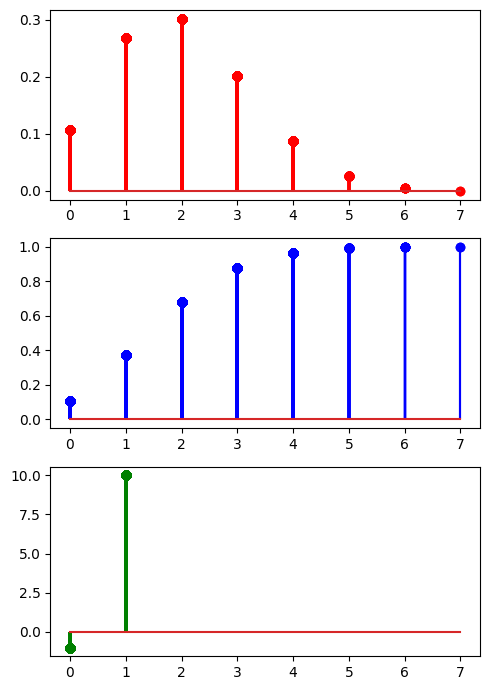

In [113]:
import matplotlib.pyplot as plt

np.random.seed(42)

size = 10
prob = 0.2
data = rbinom(2000, size = 10, prob = 0.2)

pmf = dbinom(data, size = size, prob = prob)
cdf = pbinom(data, size = size, prob = prob)
ppf = qbinom(data, size = size, prob = prob)

fig, axis = plt.subplots(3, 1, figsize = (5, 7))

axis[0].stem(data, pmf, "r-")
axis[1].stem(data, cdf, "b-")
axis[2].stem(data, ppf, "g-")

# Adjust the layout
plt.tight_layout()

# Show the plot
plt.show()

## Ejercicio 1

Escriba las funciones anteriores pero para distribuciones normales y uniformes.

In [114]:
# TODO
from scipy.stats import norm, uniform
import numpy as np
import matplotlib.pyplot as plt



In [115]:
# Generamos las funciones anteriores pero para distribuciones normales

def dnorm(x, mean=0, sd=1):
    """Calcula la función de densidad de probabilidad (PDF) de la normal."""
    return norm.pdf(x, loc=mean, scale=sd)

def pnorm(q, mean=0, sd=1):
    """Calcula el acumulado (CDF) de la distribución normal."""
    return norm.cdf(q, loc=mean, scale=sd)

def qnorm(p, mean=0, sd=1):
    """Calcula la función cuantil (PPF) de la distribución normal."""
    return norm.ppf(p, loc=mean, scale=sd)

def rnorm(n, mean=0, sd=1):
    """Genera variables aleatorias a partir de la distribución normal."""
    return norm.rvs(loc=mean, scale=sd, size=n)

In [116]:
np.random.seed(42)
# Ejemplos de consola para la Normal
print("--- Distribución Normal(0, 1) ---")
print(f"Densidad en x=0: {dnorm(0)}")
print(f"Probabilidad acumulada hasta 0: {pnorm(0)}")
print(f"Valor con probabilidad acumulada de 0.9: {qnorm(0.9)}")
print(f"Generar 5 valores aleatorios: {rnorm(5)}\n")

--- Distribución Normal(0, 1) ---
Densidad en x=0: 0.3989422804014327
Probabilidad acumulada hasta 0: 0.5
Valor con probabilidad acumulada de 0.9: 1.2815515655446004
Generar 5 valores aleatorios: [ 0.49671415 -0.1382643   0.64768854  1.52302986 -0.23415337]



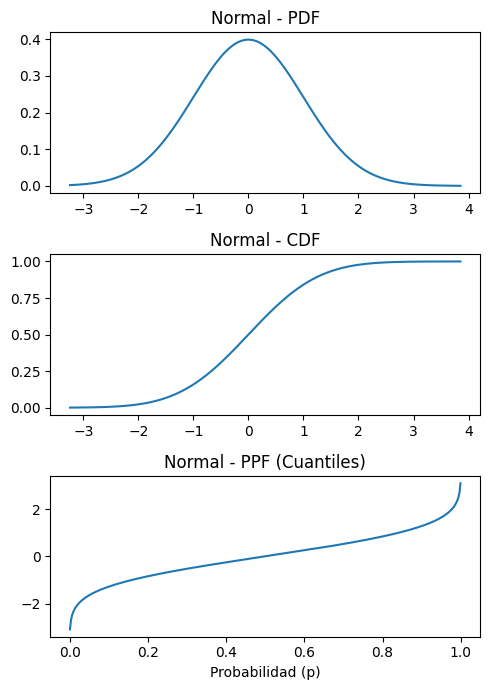

In [132]:
# Generamos gráfico con Estructura Normal: PDF, CDF, PPF
np.random.seed(42)

# Parámetros de la Normal
mean = 0
sd = 1

# "Data" simulada (como en tu ejemplo binomial)
data = norm.rvs(loc=mean, scale=sd, size=2000)

# Para graficar bonito (continuo), usamos un eje x ordenado (grilla)
x = np.linspace(data.min(), data.max(), 400)

pdf = norm.pdf(x, loc=mean, scale=sd)
cdf = norm.cdf(x, loc=mean, scale=sd)

# PPF necesita probabilidades (0 a 1), no valores de x
p = np.linspace(0.001, 0.999, 400)
ppf = norm.ppf(p, loc=mean, scale=sd)

fig, axis = plt.subplots(3, 1, figsize=(5, 7))

axis[0].plot(x, pdf)
axis[0].set_title("Normal - PDF")

axis[1].plot(x, cdf)
axis[1].set_title("Normal - CDF")

axis[2].plot(p, ppf)
axis[2].set_title("Normal - PPF (Cuantiles)")
axis[2].set_xlabel("Probabilidad (p)")

plt.tight_layout()
plt.show()

In [133]:
# Generamos las funciones anteriores pero para distribuciones uniformes

def dunif(x, min_val=0, max_val=1):
    """Calcula la función de densidad de probabilidad (PDF) de la uniforme."""
    return uniform.pdf(x, loc=min_val, scale=max_val-min_val)

def punif(q, min_val=0, max_val=1):
    """Calcula el acumulado (CDF) de la distribución uniforme."""
    return uniform.cdf(q, loc=min_val, scale=max_val-min_val)

def qunif(p, min_val=0, max_val=1):
    """Calcula la función cuantil (PPF) de la distribución uniforme."""
    return uniform.ppf(p, loc=min_val, scale=max_val-min_val)

def runif(n, min_val=0, max_val=1):
    """Genera variables aleatorias a partir de la distribución uniforme."""
    return uniform.rvs(loc=min_val, scale=max_val-min_val, size=n)

In [134]:
np.random.seed(42)
# Ejemplos de consola para la Uniforme
print("--- Distribución Uniforme(0, 1) ---")
print(f"Densidad en x=0.5: {dunif(0.5)}")
print(f"Probabilidad acumulada hasta 0.5: {punif(0.5)}")
print(f"Valor con probabilidad acumulada de 0.9: {qunif(0.9)}")
print(f"Generar 5 valores aleatorios: {runif(5)}\n")

--- Distribución Uniforme(0, 1) ---
Densidad en x=0.5: 1.0
Probabilidad acumulada hasta 0.5: 0.5
Valor con probabilidad acumulada de 0.9: 0.9
Generar 5 valores aleatorios: [0.37454012 0.95071431 0.73199394 0.59865848 0.15601864]



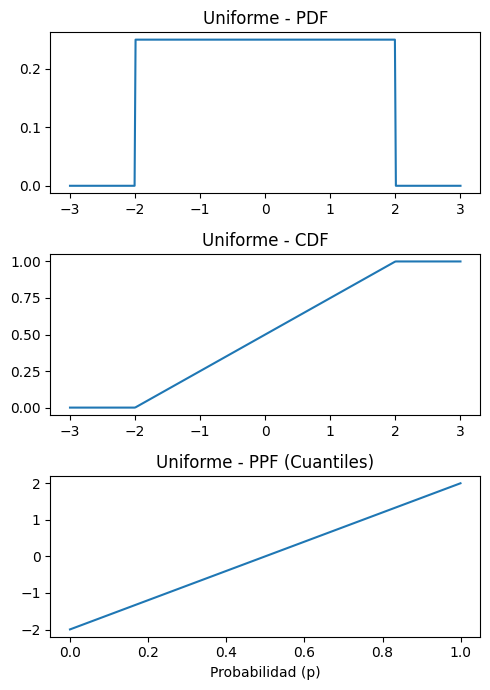

In [135]:
# Generamos gráfico con Estructura Uniforme: PDF, CDF, PPF
np.random.seed(42)

# Parámetros de la Uniforme
a = -2
b = 2

# "Data" simulada
data = uniform.rvs(loc=a, scale=b-a, size=2000)

# Grilla x para graficar continuo
x = np.linspace(a - 1, b + 1, 400)

pdf = uniform.pdf(x, loc=a, scale=b-a)
cdf = uniform.cdf(x, loc=a, scale=b-a)

# PPF (cuantiles) con probabilidades
p = np.linspace(0.001, 0.999, 400)
ppf = uniform.ppf(p, loc=a, scale=b-a)

fig, axis = plt.subplots(3, 1, figsize=(5, 7))

axis[0].plot(x, pdf)
axis[0].set_title("Uniforme - PDF")

axis[1].plot(x, cdf)
axis[1].set_title("Uniforme - CDF")

axis[2].plot(p, ppf)
axis[2].set_title("Uniforme - PPF (Cuantiles)")
axis[2].set_xlabel("Probabilidad (p)")

plt.tight_layout()
plt.show()